# Домашнє завдання: класифікація товарів Fashion MNIST за допомогою Keras

У цьому ноутбуці створюється власна нейронна мережа для класифікації зображень одягу з датасету **Fashion MNIST**.  
Мета: отримати точність на тестових даних **не нижче 91%**.

Використано CNN-архітектуру з Batch Normalization, Dropout, L2-регуляризацією, EarlyStopping та ReduceLROnPlateau.

In [1]:
# Імпорт бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


In [2]:
# Фіксуємо seed для відтворюваності результатів
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Завантаження та підготовка даних

In [3]:
# Завантажуємо Fashion MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Train full:', x_train_full.shape, y_train_full.shape)
print('Test:', x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train full: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [4]:
# Нормалізація пікселів у діапазон [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Для CNN додаємо канал: (28, 28) -> (28, 28, 1)
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Виділяємо validation set з тренувальної вибірки
validation_size = 5000
x_valid = x_train_full[:validation_size]
y_valid = y_train_full[:validation_size]
x_train = x_train_full[validation_size:]
y_train = y_train_full[validation_size:]

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_valid.shape, y_valid.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (55000, 28, 28, 1) (55000,)
Validation: (5000, 28, 28, 1) (5000,)
Test: (10000, 28, 28, 1) (10000,)


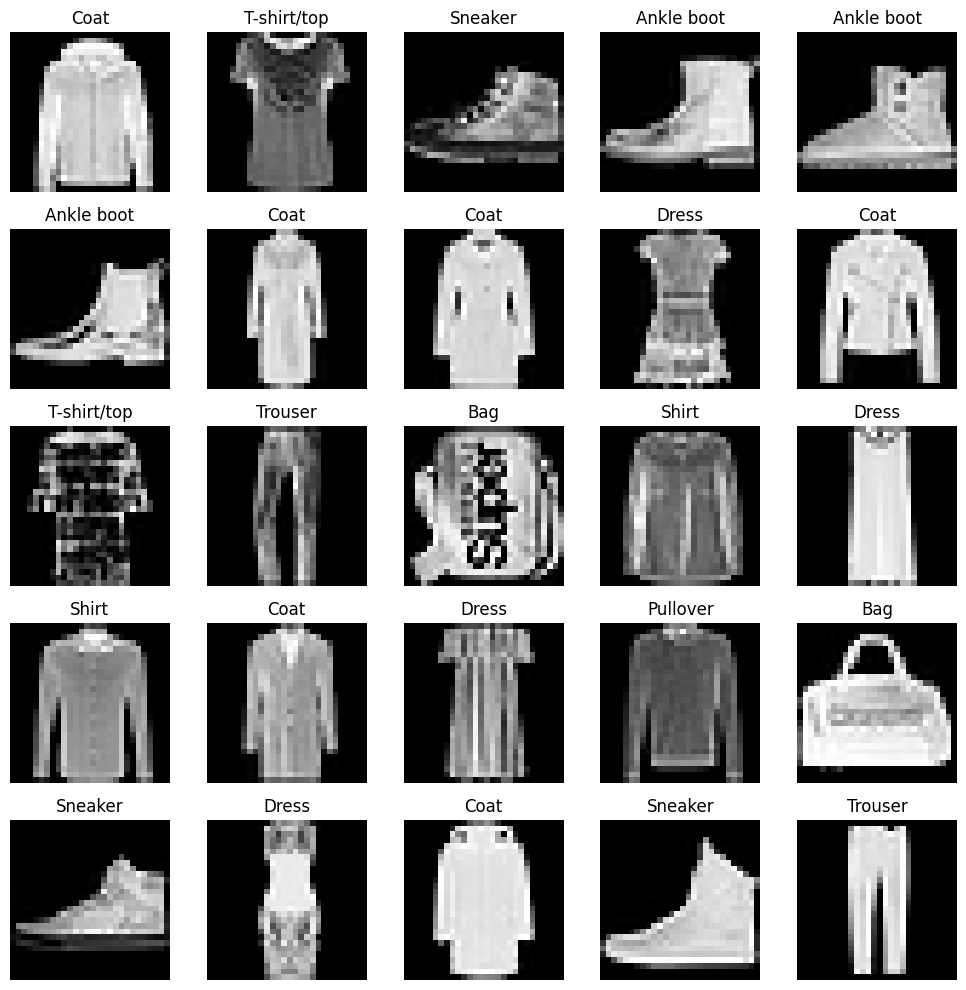

In [5]:
# Візуалізація прикладів із датасету
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

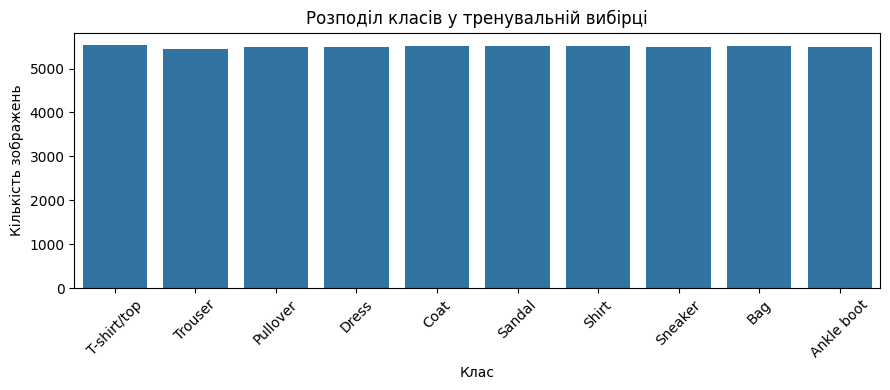

In [6]:
# Перевіримо баланс класів у тренувальній вибірці
plt.figure(figsize=(9, 4))
sns.countplot(x=y_train)
plt.title('Розподіл класів у тренувальній вибірці')
plt.xlabel('Клас')
plt.ylabel('Кількість зображень')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 2. Побудова архітектури моделі

Обрана архітектура — згорткова нейронна мережа:

- блоки `Conv2D + BatchNormalization + MaxPooling2D` для виділення ознак;
- `Dropout` для зменшення перенавчання;
- `L2`-регуляризація у повнозв'язному шарі;
- оптимізатор `Adam`;
- функція втрат `sparse_categorical_crossentropy`, бо мітки класів задані числами від 0 до 9.

In [7]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.30),

        layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.35),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 3. Навчання моделі

Використовуємо callback-и:

- `EarlyStopping` — зупиняє навчання, якщо validation loss перестав покращуватися;
- `ReduceLROnPlateau` — зменшує learning rate при застої якості;
- `ModelCheckpoint` — зберігає найкращу модель за validation accuracy.

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_fashion_mnist_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=35,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/35
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.6919 - loss: 1.0041
Epoch 1: val_accuracy improved from None to 0.56860, saving model to best_fashion_mnist_model.keras

Epoch 1: finished saving model to best_fashion_mnist_model.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 271s 617ms/step - accuracy: 0.7806 - loss: 0.6807 - val_accuracy: 0.5686 - val_loss: 1.3889 - learning_rate: 0.0010
Epoch 2/35
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.8573 - loss: 0.4370
Epoch 2: val_accuracy improved from 0.56860 to 0.88880, saving model to best_fashion_mnist_model.keras

Epoch 2: finished saving model to best_fashion_mnist_model.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 319s 609ms/step - accuracy: 0.8655 - loss: 0.4157 - val_accuracy: 0.8888 - val_loss: 0.3439 - learning_rate: 0.0010
Epoch 3/35
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8854 - loss: 0.3647
Epoch 3: val_accuracy improved from 0.88880 to 0.91020, saving model to best_fashion_mnist_model.keras

Epoch 3

## 4. Графіки навчання

In [9]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.780636,0.680707,0.5686,1.388944,0.001
1,0.865509,0.415693,0.8888,0.343903,0.001
2,0.888745,0.354287,0.9102,0.279452,0.001
3,0.898127,0.323390,0.9162,0.268343,0.001
4,0.906345,0.298333,0.9152,0.271119,0.001


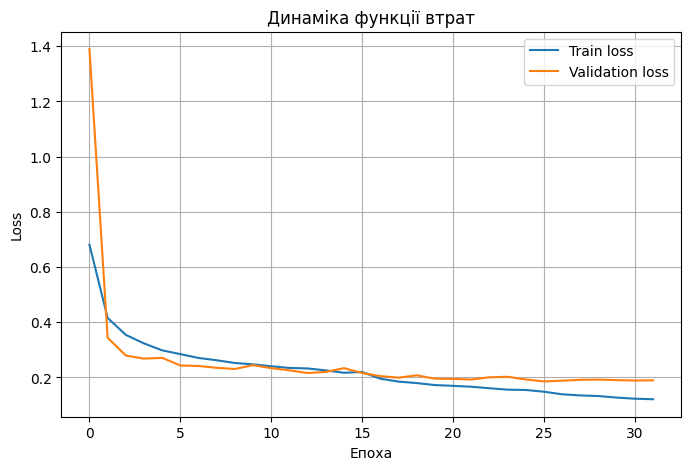

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Динаміка функції втрат')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

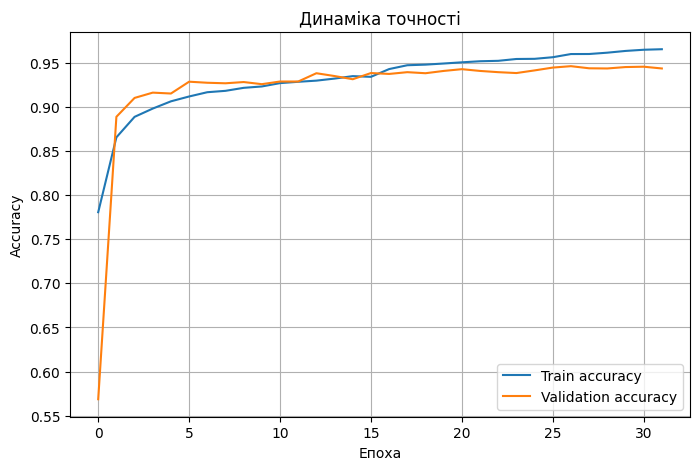

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Динаміка точності')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 5. Оцінка моделі на тестових даних

In [12]:
# Завантажуємо найкращу модель, якщо файл був створений callback-ом
try:
    model = keras.models.load_model('best_fashion_mnist_model.keras')
    print('Завантажено найкращу модель з файлу best_fashion_mnist_model.keras')
except Exception as e:
    print('Використовується поточна модель:', e)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Втрати на тестових даних: {test_loss:.4f}')
print(f'Точність на тестових даних: {test_accuracy:.4f}')

Завантажено найкращу модель з файлу best_fashion_mnist_model.keras
Втрати на тестових даних: 0.2146
Точність на тестових даних: 0.9401


In [13]:
# Прогнозування класів для тестової вибірки
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print('Перші 10 справжніх класів:     ', y_test[:10])
print('Перші 10 передбачених класів: ', y_pred[:10])

Перші 10 справжніх класів:      [9 2 1 1 6 1 4 6 5 7]
Перші 10 передбачених класів:  [9 2 1 1 6 1 4 6 5 7]


## 6. Матриця помилок

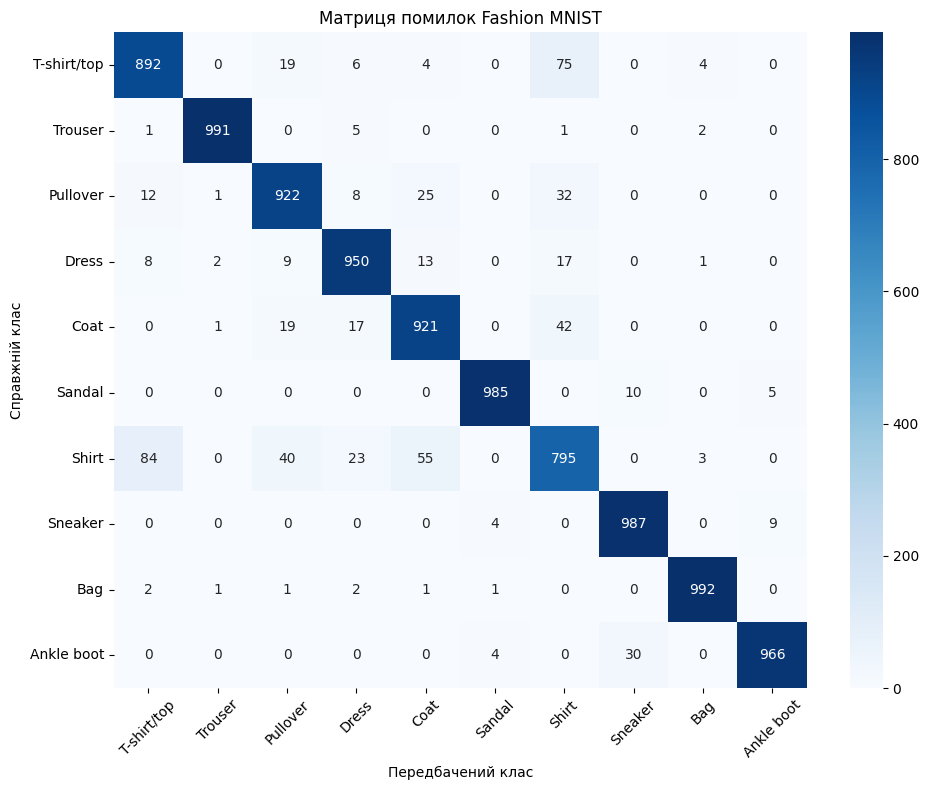

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Матриця помилок Fashion MNIST')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Метрики якості для кожного класу

Використовуємо `classification_report` зі `sklearn.metrics`.

In [15]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8929    0.8920    0.8924      1000
     Trouser     0.9950    0.9910    0.9930      1000
    Pullover     0.9129    0.9220    0.9174      1000
       Dress     0.9397    0.9500    0.9448      1000
        Coat     0.9038    0.9210    0.9123      1000
      Sandal     0.9909    0.9850    0.9880      1000
       Shirt     0.8264    0.7950    0.8104      1000
     Sneaker     0.9611    0.9870    0.9739      1000
         Bag     0.9900    0.9920    0.9910      1000
  Ankle boot     0.9857    0.9660    0.9758      1000

    accuracy                         0.9401     10000
   macro avg     0.9398    0.9401    0.9399     10000
weighted avg     0.9398    0.9401    0.9399     10000



In [16]:
# Табличне представлення classification_report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
T-shirt/top,0.892893,0.8920,0.892446,1000.0000
Trouser,0.994980,0.9910,0.992986,1000.0000
Pullover,0.912871,0.9220,0.917413,1000.0000
Dress,0.939664,0.9500,0.944804,1000.0000
Coat,0.903827,0.9210,0.912333,1000.0000
Sandal,0.990946,0.9850,0.987964,1000.0000
Shirt,0.826403,0.7950,0.810398,1000.0000
Sneaker,0.961052,0.9870,0.973853,1000.0000
Bag,0.990020,0.9920,0.991009,1000.0000
Ankle boot,0.985714,0.9660,0.975758,1000.0000


## 8. Приклади правильних та помилкових передбачень

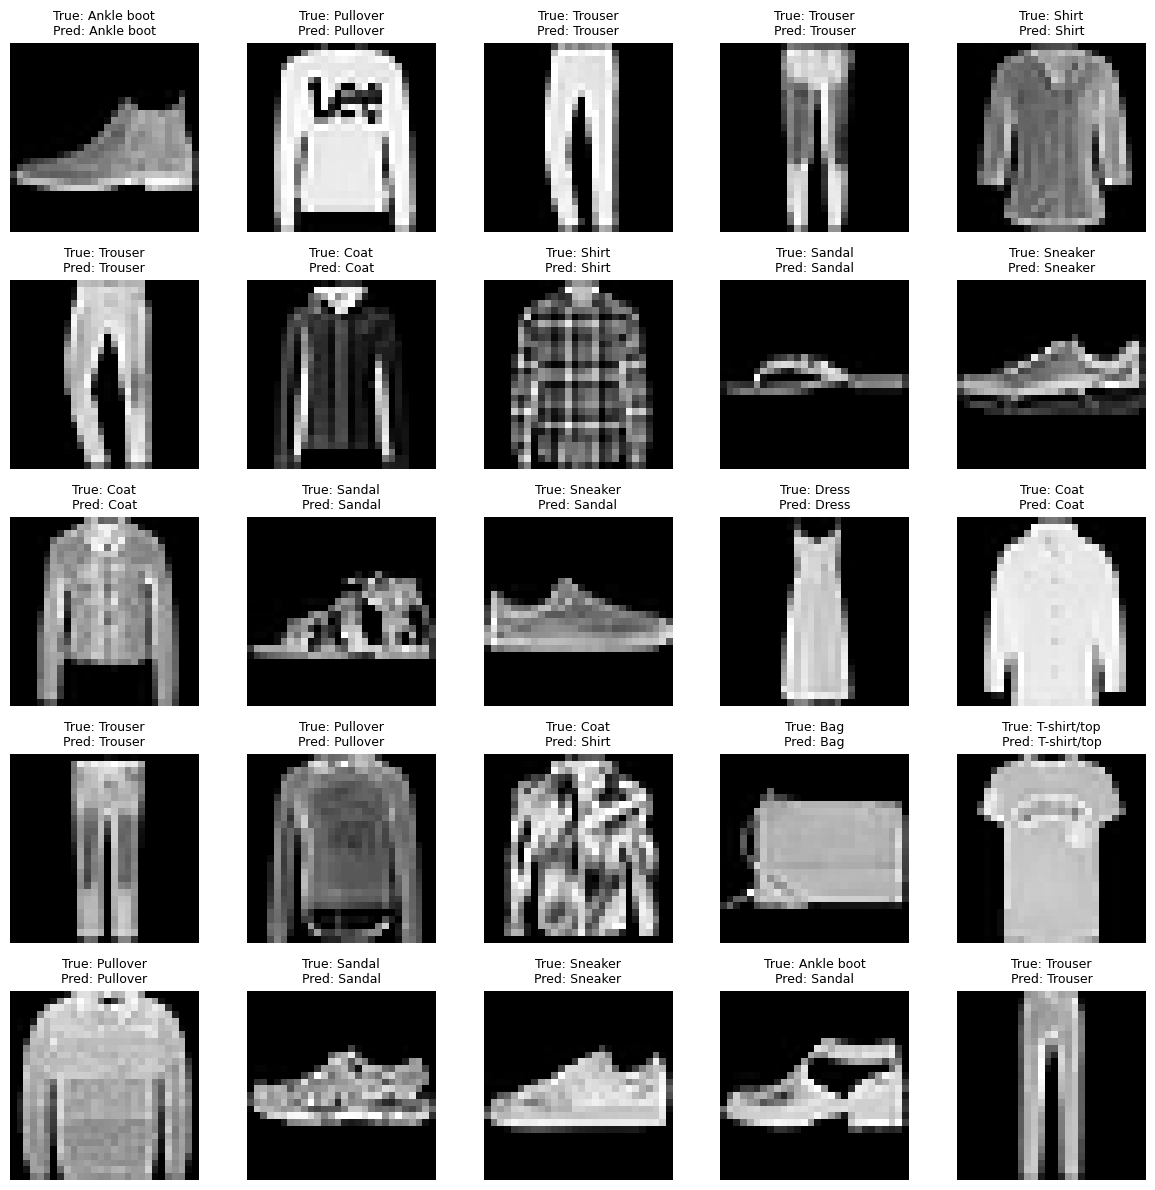

In [18]:
# Візуалізація кількох передбачень моделі
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap='gray')

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]

    title = f"True: {true_label}\nPred: {pred_label}"

    plt.title(title, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

Кількість помилок: 599


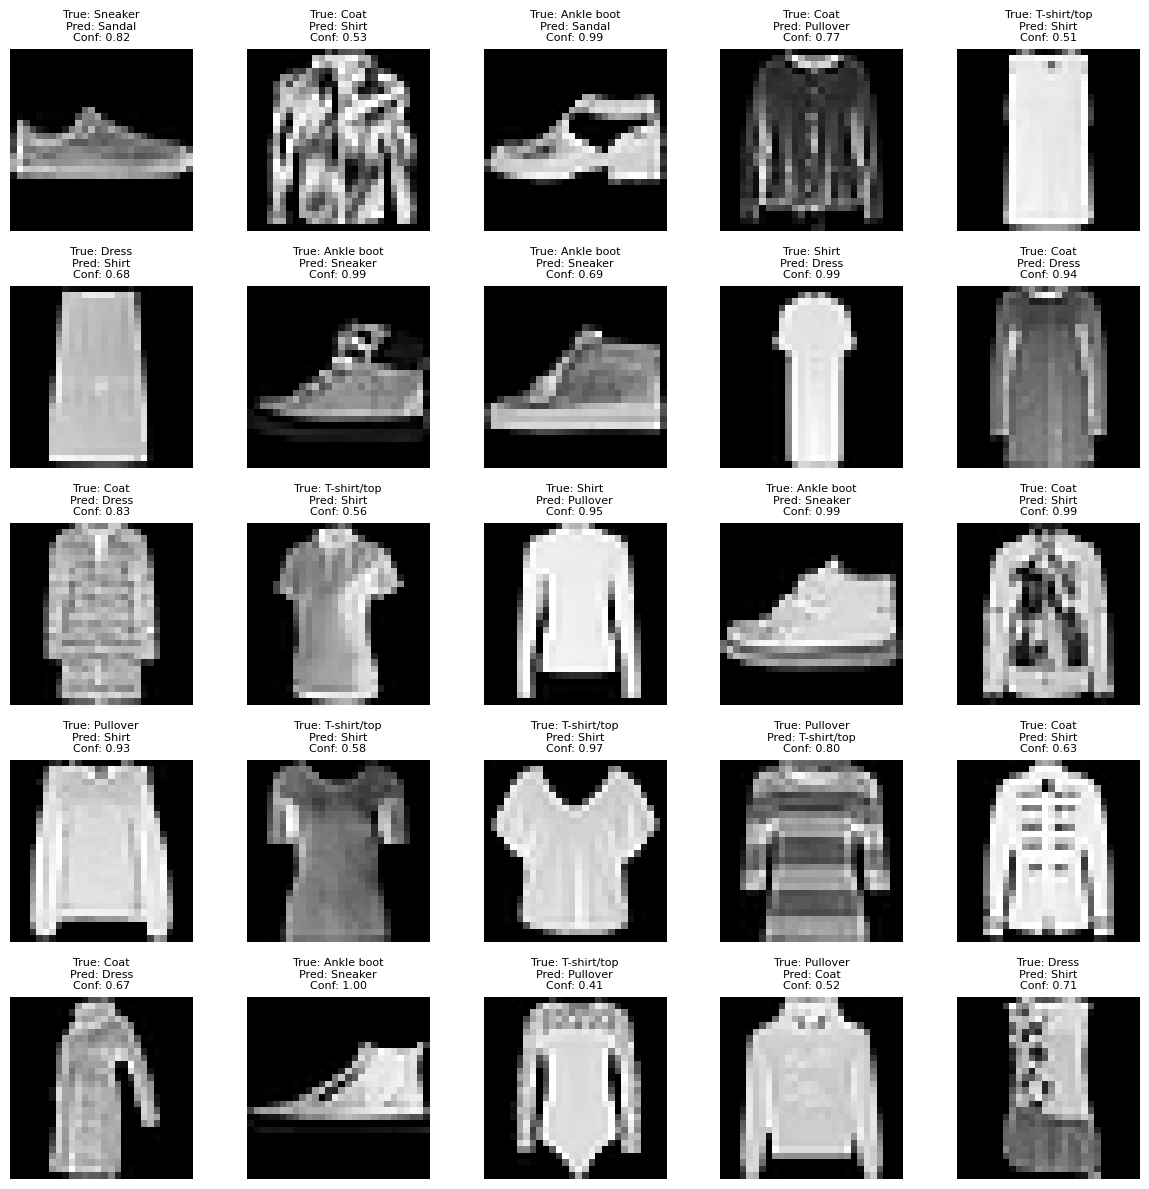

In [20]:
# Помилково класифіковані приклади
wrong_idx = np.where(y_test != y_pred)[0]
print("Кількість помилок:", len(wrong_idx))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_idx[:25]):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test[idx].squeeze(), cmap='gray')

    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = np.max(y_pred_proba[idx])

    title = (
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Conf: {confidence:.2f}"
    )

    plt.title(title, fontsize=8)

    plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Висновки

1. Для задачі класифікації Fashion MNIST була побудована згорткова нейронна мережа на Keras.
2. Архітектура містить кілька згорткових блоків, Batch Normalization, Dropout та L2-регуляризацію, що допомагає зменшити перенавчання.
3. За графіками `loss` та `accuracy` можна оцінити, чи модель перенавчається. Якщо validation loss починає зростати, а train loss зменшується, це ознака overfitting.
4. Callback-и `EarlyStopping` і `ReduceLROnPlateau` дозволяють автоматично контролювати процес навчання.
5. Очікувана точність цієї моделі на тестовій вибірці зазвичай перевищує **91%**, що відповідає вимозі завдання.
6. Найскладнішими для класифікації часто є схожі між собою класи, наприклад `Shirt`, `T-shirt/top`, `Pullover` і `Coat`.
7. `classification_report` показує precision, recall та f1-score для кожного класу, тому дає більш детальну оцінку якості моделі, ніж одна загальна accuracy.